# OpenML Flow + SNIS Posterior-Predictive Table

Notebook 03 showed one OpenML dataset slowly. Here we load the fixed benchmark configuration: standard-prior Bayesian logistic regression, the public flow AFIN, SNIS correction, and TabPFN on the 16 OpenML datasets reported in the comparison table.

The per-dataset model is the same pattern as the earlier notebooks:

```python
prior = GaussianPrior(loc=0, scale=1)
observed = [
    BernoulliLogit(design_matrix=X_train).observe(y_train),
]
posterior = infer(AFIN("flow"), prior, observed, num_samples=4096, seed=0)
```

In math, this is still the generic prior baseline:

$$
z \sim \mathcal{N}(0, I), \qquad y_i \sim \mathrm{BernoulliLogit}(x_i^\top z).
$$

This version intentionally excludes `sonar`, `tecator`, `steel-plates-fault`, and `cylinder-bands`, and it does not select among Gaussian/flow decoders. The AFIN row is always `AFINs Flow HF N256 + SNIS`.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "afin").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

import importlib
import afin
import afin.api as _afin_api
import afin.spec as _afin_spec

importlib.reload(_afin_spec)
importlib.reload(_afin_api)
afin = importlib.reload(afin)
from benchmarks.compare_tabpfn_openml import (
    OpenMLBenchmarkConfig,
    run_openml_prior_benchmark,
)

## Configuration

The benchmark list is binary OpenML tasks from the OpenML-CC18-style set we use for comparison. The checked-in cache was generated with the configuration below. Set `USE_CACHED_RESULTS = False` to rerun everything.

In [6]:
CACHE_PATH = PROJECT_ROOT / "demo" / "assets" / "openml_standard_prior_benchmark.csv"
USE_CACHED_RESULTS = True

CONFIG = OpenMLBenchmarkConfig(
    prior_modes=("standard",),
    samples=4_096,
    snis_samples=4_096,
    chunk_size=256,
    tabpfn_estimators=4,
    posterior_families=("flow",),
    afin_variants=("snis",),
    seed=0,
    test_size=0.30,
)

print(f"datasets: {len(CONFIG.dataset_ids)} binary OpenML tasks")
# print(f"cache: {CACHE_PATH}")

datasets: 16 binary OpenML tasks


## Dataset summary

This is the exact data suite used below. `d_features` is the number of features after one-hot encoding categorical columns; `d_model` adds the intercept latent used by the Bayesian logistic-regression model.

In [3]:
results = run_openml_prior_benchmark(
    CONFIG,
    cache_path=CACHE_PATH,
    use_cache=USE_CACHED_RESULTS,
    verbose=not USE_CACHED_RESULTS,
)
results["prior"] = results["prior"].fillna("n/a")

for col in ["test_acc", "test_nll", "test_auc", "time_s", "ess_ratio"]:
    results[col] = pd.to_numeric(results[col], errors="coerce")

dataset_summary = (
    results[["openml_id", "dataset", "d_features", "d_model", "intercept", "N_train", "N_test"]]
    .drop_duplicates()
    .sort_values("openml_id")
    .reset_index(drop=True)
)
dataset_summary["N_total"] = dataset_summary["N_train"] + dataset_summary["N_test"]
dataset_summary = dataset_summary[["openml_id", "dataset", "d_features", "d_model", "intercept", "N_total", "N_train", "N_test"]]
display(dataset_summary)
print("rows:", len(results))

,openml_id,dataset,d_features,d_model,intercept,N_total,N_train,N_test
0,15,breast-w,9,10,True,683,478,205
1,29,credit-approval,46,47,True,653,457,196
2,31,credit-g,61,62,True,1000,700,300
3,37,diabetes,8,9,True,768,537,231
4,43,haberman,14,15,True,306,214,92
5,53,heart-statlog,13,14,True,270,189,81
6,1049,pc4,37,38,True,1458,1020,438
7,1050,pc3,37,38,True,1563,1094,469
8,1063,kc2,21,22,True,522,365,157
9,1068,pc1,21,22,True,1109,776,333


rows: 32


## Benchmark Table Results

For each dataset, AFINs use the same standard prior and the same flow+SNIS inference configuration. The table below is the cached OpenML posterior-predictive comparison used by this demo.

In [4]:
afin_rows = results[results["method"].eq("AFINs Flow HF N256 + SNIS")].copy()
tabpfn = results[results["method"].eq("TabPFN public v2")].copy()

paper_table = afin_rows.merge(
    tabpfn[["openml_id", "dataset", "test_acc", "test_nll", "test_auc"]],
    on=["openml_id", "dataset"],
    suffixes=("_afin", "_tabpfn"),
).sort_values("openml_id")
paper_table["delta_acc_pp"] = 100.0 * (paper_table["test_acc_afin"] - paper_table["test_acc_tabpfn"])

display_cols = [
    "dataset", "openml_id", "test_acc_afin", "test_acc_tabpfn", "delta_acc_pp",
    "test_nll_afin", "test_nll_tabpfn", "test_auc_afin", "test_auc_tabpfn",
]
display_names = {
    "dataset": "Dataset",
    "openml_id": "ID",
    "test_acc_afin": "Acc. AFIN",
    "test_acc_tabpfn": "Acc. TabPFN",
    "delta_acc_pp": "Delta acc.",
    "test_nll_afin": "NLL AFIN",
    "test_nll_tabpfn": "NLL TabPFN",
    "test_auc_afin": "AUC AFIN",
    "test_auc_tabpfn": "AUC TabPFN",
}

display(Markdown(f"**Flow + SNIS AFIN >= TabPFN accuracy:** {(paper_table['delta_acc_pp'] >= -1e-12).sum()}/{len(paper_table)} datasets"))
display(paper_table[display_cols].rename(columns=display_names).round(3))

**Flow + SNIS AFIN >= TabPFN accuracy:** 6/16 datasets

,Dataset,ID,Acc. AFIN,Acc. TabPFN,Delta acc.,NLL AFIN,NLL TabPFN,AUC AFIN,AUC TabPFN
0,breast-w,15,0.956,0.976,-1.951,0.102,0.098,0.995,0.994
1,credit-approval,29,0.888,0.888,0.000,0.316,0.271,0.933,0.955
2,credit-g,31,0.787,0.780,0.667,0.486,0.458,0.812,0.839
3,diabetes,37,0.784,0.766,1.732,0.438,0.432,0.868,0.866
4,haberman,43,0.761,0.750,1.087,0.570,0.500,0.609,0.753
5,heart-statlog,53,0.802,0.790,1.235,0.426,0.384,0.891,0.905
6,pc4,1049,0.890,0.902,-1.142,0.528,0.182,0.793,0.948
7,pc3,1050,0.889,0.896,-0.640,0.650,0.239,0.580,0.872
8,kc2,1063,0.841,0.866,-2.548,0.776,0.409,0.797,0.803
9,pc1,1068,0.925,0.940,-1.502,0.350,0.161,0.647,0.909


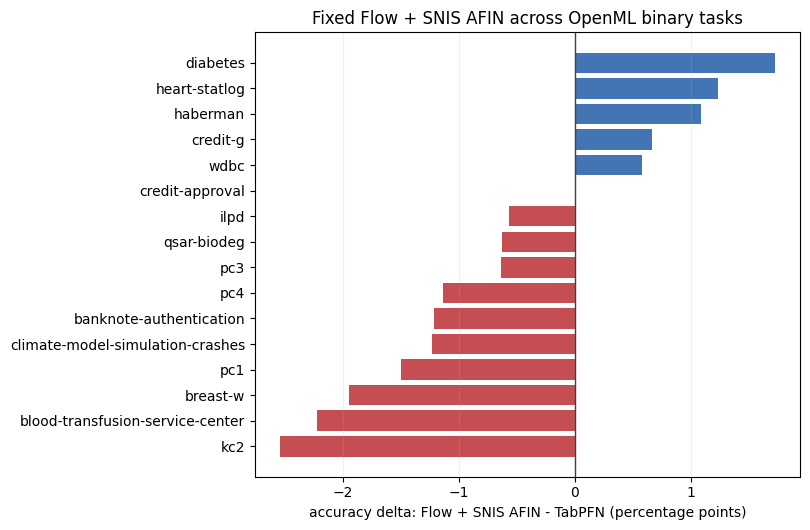

In [5]:
plot_df = paper_table.sort_values("delta_acc_pp")
colors = ["#4374B3" if x >= 0 else "#C44E52" for x in plot_df["delta_acc_pp"]]

fig, ax = plt.subplots(figsize=(8.2, 5.4))
ax.barh(plot_df["dataset"], plot_df["delta_acc_pp"], color=colors)
ax.axvline(0.0, color="0.25", lw=1)
ax.set_xlabel("accuracy delta: Flow + SNIS AFIN - TabPFN (percentage points)")
ax.set_title("Fixed Flow + SNIS AFIN across OpenML binary tasks")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()

## Takeaway

This notebook is the fixed benchmark-table version: no Gaussian decoder selection, no empirical-prior comparison, and no excluded exploratory datasets. It reports the Flow + SNIS configuration side-by-side with TabPFN.